

1.   Elemento de la lista
2.   Elemento de la lista



In [ ]:
import gdown, os

if not os.path.exists('/content/ProyectoIA'):
    gdown.download(id='1BcImkhTdVdJriK4-8HZPnvmOV7C4MZnG',
                   output='/content/mias.zip', quiet=False)
    !unzip -q /content/mias.zip -d /content/ProyectoIA

In [ ]:
!nvidia-smi -L

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Dispositivo:", device)

Dispositivo: cuda:0


In [ ]:

dataset_root = '/content/ProyectoIA'
output_dir   = '/content/ProyectoIA'
RES = 512          # resolución de entrada
bs  = 32           # batch
num_classes = 2    # normal, anomalia
epochs = 20

train_directory = dataset_root + '/train'
valid_directory = dataset_root + '/valid'
test_directory  = dataset_root + '/test'

In [ ]:
resize_eval = int(RES * 256 / 224)   # mantiene el margen

image_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),   # los .pgm son de 1 canal
        transforms.RandomResizedCrop(size=RES, scale=(0.9, 1.0)),
        transforms.RandomRotation(degrees=20),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'valid': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(size=resize_eval),
        transforms.CenterCrop(size=RES),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(size=resize_eval),
        transforms.CenterCrop(size=RES),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

In [ ]:
data = {
    'train': datasets.ImageFolder(root=train_directory, transform=image_transforms['train']),
    'valid': datasets.ImageFolder(root=valid_directory, transform=image_transforms['valid']),
    'test':  datasets.ImageFolder(root=test_directory,  transform=image_transforms['test']),
}
train_data_size = len(data['train'])
valid_data_size = len(data['valid'])
test_data_size  = len(data['test'])

train_data = DataLoader(data['train'], batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
valid_data = DataLoader(data['valid'], batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_data  = DataLoader(data['test'],  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print("train:", train_data_size, "| valid:", valid_data_size, "| test:", test_data_size)
print("clases:", data['train'].classes)   # ['anomalia', 'normal']

train: 225 | valid: 48 | test: 49
clases: ['anomalia', 'normal']


In [ ]:
# Backbone preentrenado en ImageNet (transfer learning)
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congelar todo
for param in resnet50.parameters():
    param.requires_grad = False
# descongelar solo el último bloque convolucional
for param in resnet50.layer4.parameters():
    param.requires_grad = True

fc_inputs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes),
    nn.LogSoftmax(dim=1),   # para usar con NLLLoss
)
model = resnet50.to(device)


In [ ]:
# Más peso a la clase minoritaria (anomalia) para que el modelo no colapse a
# predecir siempre "normal". Índices por orden alfabético: 0=anomalia, 1=normal.
conteo = torch.bincount(torch.tensor(data['train'].targets)).float()
pesos  = conteo.sum() / (2 * conteo)
loss_criterion = nn.NLLLoss(weight=pesos.to(device))

# lr bajo (1e-4)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=1e-4, weight_decay=1e-4)

In [ ]:
import copy
history = []
best_valid_loss = float('inf')
best_state = None

for epoch in range(epochs):
    epoch_start = time.time()
    model.train()
    train_loss = train_acc = valid_loss = valid_acc = 0.0

    for inputs, labels in train_data:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs.data, 1)
        train_acc += torch.mean(preds.eq(labels.data.view_as(preds)).type(torch.FloatTensor)).item() * inputs.size(0)

    with torch.no_grad():
        model.eval()
        for inputs, labels in valid_data:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_criterion(outputs, labels)
            valid_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs.data, 1)
            valid_acc += torch.mean(preds.eq(labels.data.view_as(preds)).type(torch.FloatTensor)).item() * inputs.size(0)

    avg_train_loss = train_loss / train_data_size
    avg_train_acc  = train_acc  / train_data_size
    avg_valid_loss = valid_loss / valid_data_size
    avg_valid_acc  = valid_acc  / valid_data_size
    history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

    # Early stopping
    marca = ""
    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_state = copy.deepcopy(model.state_dict())
        marca = "  <- mejor"

    print("Epoch {:03d} | Train loss {:.4f} acc {:.2f}% | Valid loss {:.4f} acc {:.2f}% | {:.1f}s{}".format(
        epoch, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, time.time()-epoch_start, marca))

# Restaurar el mejor modelo antes de guardar y evaluar (celdas 9 y 10)
model.load_state_dict(best_state)
print("\nMejor modelo restaurado (valid loss {:.4f}).".format(best_valid_loss))

Epoch 000 | Train loss 0.7007 acc 48.00% | Valid loss 0.6979 acc 35.42% | 25.0s  <- mejor
Epoch 001 | Train loss 0.6869 acc 66.22% | Valid loss 0.6950 acc 56.25% | 24.8s  <- mejor
Epoch 002 | Train loss 0.6951 acc 64.44% | Valid loss 0.6949 acc 52.08% | 25.2s  <- mejor
Epoch 003 | Train loss 0.6795 acc 65.33% | Valid loss 0.7019 acc 35.42% | 24.0s
Epoch 004 | Train loss 0.6797 acc 64.00% | Valid loss 0.6998 acc 41.67% | 24.7s
Epoch 005 | Train loss 0.6823 acc 65.33% | Valid loss 0.6988 acc 60.42% | 24.5s
Epoch 006 | Train loss 0.6815 acc 63.11% | Valid loss 0.6999 acc 60.42% | 25.8s
Epoch 007 | Train loss 0.6722 acc 64.89% | Valid loss 0.7044 acc 58.33% | 24.4s
Epoch 008 | Train loss 0.6716 acc 60.89% | Valid loss 0.7094 acc 47.92% | 25.0s
Epoch 009 | Train loss 0.6597 acc 64.00% | Valid loss 0.7864 acc 56.25% | 25.2s
Epoch 010 | Train loss 0.6563 acc 64.00% | Valid loss 0.9915 acc 60.42% | 23.9s
Epoch 011 | Train loss 0.6487 acc 63.56% | Valid loss 0.8799 acc 58.33% | 24.7s
Epoch 012 

Modelo guardado en /content/drive/MyDrive/ProyectoIA/modelo_512.pt


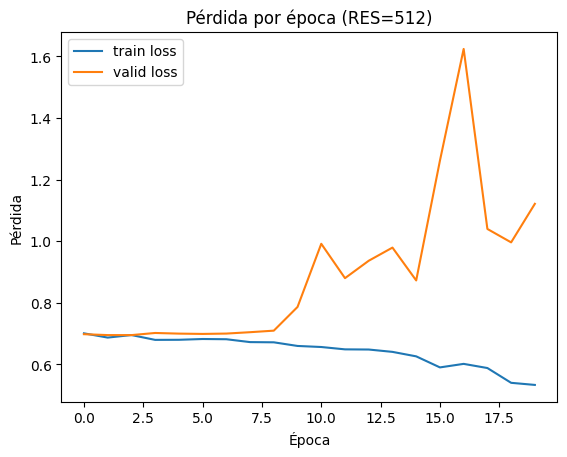

In [ ]:

import matplotlib.pyplot as plt

torch.save(model.state_dict(), output_dir + '/modelo_512.pt')
print("Modelo guardado en", output_dir + '/modelo_512.pt')

hist = torch.tensor(history)   # columnas: train_loss, valid_loss, train_acc, valid_acc
plt.figure()
plt.plot(hist[:, 0], label='train loss')
plt.plot(hist[:, 1], label='valid loss')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.title(f'Pérdida por época (RES={RES})')
plt.savefig(output_dir + '/curva_perdida_512.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_data:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.tolist())
        y_pred.extend(preds.cpu().tolist())

nombres_clase = data['test'].classes
print("=== Resultados sobre TEST (RES =", RES, ") ===")
print("Matriz de confusión (filas=real, columnas=predicho):", nombres_clase)
for nombre, fila in zip(nombres_clase, confusion_matrix(y_true, y_pred)):
    print(f"{nombre:>12}", fila)
print("\n", classification_report(y_true, y_pred, target_names=nombres_clase, zero_division=0))

=== Resultados sobre TEST (RES = 512 ) ===
Matriz de confusión (filas=real, columnas=predicho): ['anomalia', 'normal']
    anomalia [ 1 17]
      normal [ 0 31]

               precision    recall  f1-score   support

    anomalia       1.00      0.06      0.11        18
      normal       0.65      1.00      0.78        31

    accuracy                           0.65        49
   macro avg       0.82      0.53      0.45        49
weighted avg       0.78      0.65      0.54        49



In [ ]:
import time, copy
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

!wget -q -O /content/etiquetas_mias.csv https://raw.githubusercontent.com/jbonillaro-lgtm/ProjectTL/main/data/etiquetas_mias.csv

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Dispositivo:", device)


dataset_root = '/content/ProyectoIA'
csv_path     = '/content/etiquetas_mias.csv'
output_dir   = '/content/ProyectoIA'

RES   = 512
bs    = 16
epochs = 30
NORM_SCALE = 4320.0   # escala para normalizar coordenadas a ~[0,1]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo: cuda:0


In [ ]:
df = pd.read_csv(csv_path)
df_anom = df[df['clase'] == 'anomalia'].copy()   # solo imágenes con anomalía
print("Imágenes con anomalía por split:")
print(df_anom.groupby('split').size())
print("Tipos:", df_anom['tipo'].value_counts().to_dict())

# transforms
norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((RES, RES)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), norm,
])
tf_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((RES, RES)),
    transforms.ToTensor(), norm,
])

def ruta(row):
    return f"{dataset_root}/{row['split']}/{row['clase']}/{row['filename']}"

#  clasificación del tipo
TIPOS = ['CALC', 'CIRC', 'SPIC', 'MISC', 'ARCH', 'ASYM']
tipo2idx = {t: i for i, t in enumerate(TIPOS)}

class DatasetTipo(Dataset):
    def __init__(self, split, tf):
        self.rows = df_anom[df_anom['split'] == split].reset_index(drop=True)
        self.tf = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = self.tf(Image.open(ruta(r)))
        return img, tipo2idx[r['tipo']]

# regresión de (x, y, radio)
df_loc = df_anom.dropna(subset=['x', 'y', 'radio']).copy()   # solo con coordenadas

class DatasetLoc(Dataset):
    def __init__(self, split, tf):
        self.rows = df_loc[df_loc['split'] == split].reset_index(drop=True)
        self.tf = tf
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        img = self.tf(Image.open(ruta(r)))
        target = torch.tensor([float(r['x']), float(r['y']), float(r['radio'])], dtype=torch.float) / NORM_SCALE
        return img, target

print("OK datasets definidos")

Imágenes con anomalía por split:
split
test     18
train    80
valid    17
dtype: int64
Tipos: {'CALC': 25, 'CIRC': 23, 'SPIC': 19, 'ARCH': 19, 'ASYM': 15, 'MISC': 14}
OK datasets definidos


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
tr = DataLoader(DatasetTipo('train', tf_train), batch_size=bs, shuffle=True,  num_workers=2, drop_last=True)
va = DataLoader(DatasetTipo('valid', tf_eval),  batch_size=bs, shuffle=False, num_workers=2)
te = DataLoader(DatasetTipo('test',  tf_eval),  batch_size=bs, shuffle=False, num_workers=2)

modelo = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in modelo.parameters(): p.requires_grad = False
for p in modelo.layer4.parameters(): p.requires_grad = True
modelo.fc = nn.Sequential(nn.Linear(modelo.fc.in_features, 256), nn.ReLU(),
                          nn.Dropout(0.4), nn.Linear(256, len(TIPOS)))
modelo = modelo.to(device)

# pesos por clase
cuenta = df_anom[df_anom['split']=='train']['tipo'].value_counts()
w = torch.tensor([len(DatasetTipo('train', tf_eval)) / (len(TIPOS) * cuenta.get(t, 1)) for t in TIPOS], dtype=torch.float)
crit = nn.CrossEntropyLoss(weight=w.to(device))
opt  = optim.Adam(filter(lambda p: p.requires_grad, modelo.parameters()), lr=1e-4, weight_decay=1e-4)

best_loss, best_state = float('inf'), None
for e in range(epochs):
    modelo.train(); tl = 0.0
    for x, y in tr:
        x, y = x.to(device), y.to(device)
        opt.zero_grad(); out = modelo(x); loss = crit(out, y); loss.backward(); opt.step()
        tl += loss.item() * x.size(0)
    modelo.eval(); vl = 0.0
    with torch.no_grad():
        for x, y in va:
            x, y = x.to(device), y.to(device)
            vl += crit(modelo(x), y).item() * x.size(0)
    vl /= max(len(va.dataset), 1)
    if vl < best_loss: best_loss, best_state = vl, copy.deepcopy(modelo.state_dict())
    if e % 5 == 0 or e == epochs-1:
        print(f"Epoch {e:02d} | train loss {tl/len(tr.dataset):.4f} | valid loss {vl:.4f}")

modelo.load_state_dict(best_state)
torch.save(modelo.state_dict(), output_dir + '/modelo_tipo.pt')

# Evaluación en test
modelo.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for x, y in te:
        p = modelo(x.to(device)).argmax(1).cpu().tolist()
        y_pred += p; y_true += y.tolist()
labels_pres = sorted(set(y_true) | set(y_pred))
print("\n=== ETAPA 2: TIPO DE ANOMALIA (test) ===")
print(confusion_matrix(y_true, y_pred, labels=labels_pres))
print(classification_report(y_true, y_pred, labels=labels_pres,
      target_names=[TIPOS[i] for i in labels_pres], zero_division=0))


Epoch 00 | train loss 1.8013 | valid loss 1.8001
Epoch 05 | train loss 1.6334 | valid loss 1.8088
Epoch 10 | train loss 1.2517 | valid loss 1.8334
Epoch 15 | train loss 0.6174 | valid loss 1.8981
Epoch 20 | train loss 0.0738 | valid loss 2.4303
Epoch 25 | train loss 0.0227 | valid loss 2.9546
Epoch 29 | train loss 0.0110 | valid loss 2.7172

=== ETAPA 2: TIPO DE ANOMALIA (test) ===
[[0 0 0 0 0 2]
 [2 0 0 1 0 1]
 [0 1 0 0 1 1]
 [0 1 0 1 1 0]
 [1 0 1 0 1 0]
 [0 1 0 1 0 1]]
              precision    recall  f1-score   support

        CALC       0.00      0.00      0.00         2
        CIRC       0.00      0.00      0.00         4
        SPIC       0.00      0.00      0.00         3
        MISC       0.33      0.33      0.33         3
        ARCH       0.33      0.33      0.33         3
        ASYM       0.20      0.33      0.25         3

    accuracy                           0.17        18
   macro avg       0.14      0.17      0.15        18
weighted avg       0.14      0.17   

In [ ]:
tr = DataLoader(DatasetLoc('train', tf_train), batch_size=bs, shuffle=True,  num_workers=2, drop_last=True)
va = DataLoader(DatasetLoc('valid', tf_eval),  batch_size=bs, shuffle=False, num_workers=2)
te = DataLoader(DatasetLoc('test',  tf_eval),  batch_size=bs, shuffle=False, num_workers=2)

modelo = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in modelo.parameters(): p.requires_grad = False
for p in modelo.layer4.parameters(): p.requires_grad = True
modelo.fc = nn.Sequential(nn.Linear(modelo.fc.in_features, 256), nn.ReLU(),
                          nn.Dropout(0.4), nn.Linear(256, 3))   # x, y, radio (normalizados)
modelo = modelo.to(device)

crit = nn.SmoothL1Loss()
opt  = optim.Adam(filter(lambda p: p.requires_grad, modelo.parameters()), lr=1e-4, weight_decay=1e-4)

best_loss, best_state = float('inf'), None
for e in range(epochs):
    modelo.train(); tl = 0.0
    for x, t in tr:
        x, t = x.to(device), t.to(device)
        opt.zero_grad(); loss = crit(modelo(x), t); loss.backward(); opt.step()
        tl += loss.item() * x.size(0)
    modelo.eval(); vl = 0.0
    with torch.no_grad():
        for x, t in va:
            x, t = x.to(device), t.to(device)
            vl += crit(modelo(x), t).item() * x.size(0)
    vl /= max(len(va.dataset), 1)
    if vl < best_loss: best_loss, best_state = vl, copy.deepcopy(modelo.state_dict())
    if e % 5 == 0 or e == epochs-1:
        print(f"Epoch {e:02d} | train loss {tl/len(tr.dataset):.4f} | valid loss {vl:.4f}")

modelo.load_state_dict(best_state)
torch.save(modelo.state_dict(), output_dir + '/modelo_loc.pt')

# Evaluación: error medio absoluto en píxeles (desnormalizado)
modelo.eval(); errs = []
with torch.no_grad():
    for x, t in te:
        pred = modelo(x.to(device)).cpu()
        errs.append((pred - t).abs() * NORM_SCALE)   # a píxeles
errs = torch.cat(errs).mean(0)
print("\n=== ETAPA 3: LOCALIZACION (test) ===")
print(f"Error medio absoluto -> x: {errs[0]:.0f} px | y: {errs[1]:.0f} px | radio: {errs[2]:.0f} px")


Epoch 00 | train loss 0.0541 | valid loss 0.0376
Epoch 05 | train loss 0.0082 | valid loss 0.0253
Epoch 10 | train loss 0.0038 | valid loss 0.0127
Epoch 15 | train loss 0.0031 | valid loss 0.0063
Epoch 20 | train loss 0.0027 | valid loss 0.0049
Epoch 25 | train loss 0.0023 | valid loss 0.0047
Epoch 29 | train loss 0.0024 | valid loss 0.0049

=== ETAPA 3: LOCALIZACION (test) ===
Error medio absoluto -> x: 639 px | y: 384 px | radio: 116 px
